In [ ]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Model
from keras.layers import Input, Conv1D, LSTM, Dense, Concatenate
from keras.layers import GlobalAveragePooling1D, Multiply, Dropout
from keras.layers import BatchNormalization, Softmax
from keras.optimizers import Adam
import shap
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("wustl-ehms-2020_with_attacks_categories.csv")
enc = LabelEncoder()
y = enc.fit_transform(df['Attack Category'])

cols = df.drop(columns=['Label', 'Attack Category'], errors='ignore')
X_df = cols.select_dtypes(include=[np.number]).fillna(0)
X, feats = X_df.values, X_df.columns.tolist()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).reshape(-1, X.shape[1], 1)
X_test = scaler.transform(X_test).reshape(-1, X.shape[1], 1)
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

In [ ]:
inputs = Input(shape=(X.shape[1], 1))

cnn_b = Conv1D(128, 3, activation='relu', padding='same')(inputs)
cnn_a = Softmax(axis=1)(Dense(1, activation='tanh')(cnn_b))
cnn = Dense(42, activation='relu')(GlobalAveragePooling1D()(Multiply()([cnn_b, cnn_a])))


In [ ]:
lstm_b = LSTM(64, return_sequences=True)(inputs)
lstm_a = Softmax(axis=1)(Dense(1, activation='tanh')(lstm_b))
lstm = Dense(42, activation='relu')(GlobalAveragePooling1D()(Multiply()([lstm_b, lstm_a])))


In [ ]:
fused = Multiply()([cnn, lstm])
merged = Concatenate()([cnn, lstm, fused])
merged = Dropout(0.1105123161523788)(BatchNormalization()(merged))

In [ ]:
from keras.callbacks import EarlyStopping

out = Dense(len(enc.classes_), activation='softmax')(Dense(42, activation='relu')(merged))
model = Model(inputs, out)
model.compile(optimizer=Adam(learning_rate=0.008268126053057996), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
print("\nTraining CNN-LSTM Model...")
history = model.fit(X_train, y_train,  epochs=100, batch_size=64, validation_split=0.2, class_weight=class_weights,
                    callbacks=[early_stop],
                    verbose=1)


Training CNN-LSTM Model...
Epoch 1/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5144 - loss: 0.5996 - val_accuracy: 0.0726 - val_loss: 1.1998
Epoch 2/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5558 - loss: 0.5250 - val_accuracy: 0.0941 - val_loss: 1.0386
Epoch 3/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5578 - loss: 0.5256 - val_accuracy: 0.4105 - val_loss: 0.7890
Epoch 4/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5574 - loss: 0.4955 - val_accuracy: 0.8906 - val_loss: 0.4846
Epoch 5/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5617 - loss: 0.4614 - val_accuracy: 0.8341 - val_loss: 0.6741
Epoch 6/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5638 - loss: 0.4703 - val_accuracy: 0.1077 - val_loss: 1.7342
Epoch 7/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5668 - loss: 0.4656 - val_accuracy: 0.4814 - val_loss: 0.7720
Epoch 8/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accura

In [ ]:
normal_id = list(enc.classes_).index('normal')
attack_ids = np.where(y_test != normal_id)[0]
random_id = np.random.choice(attack_ids)

test_sample_3d = X_test[random_id:random_id+1]
true_label = y_test[random_id]

prediction_probs = model.predict(test_sample_3d, verbose=0)[0]
predicted_label = np.argmax(prediction_probs)

print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f" FINAL TEST ACCURACY: {accuracy * 100:.2f}% ")

print(f"\nPredicted : {enc.classes_[predicted_label].upper()}")
print(f"Truth     : {enc.classes_[true_label].upper()}")



Evaluating Model on Test Data...
 FINAL TEST ACCURACY: 90.67% 

Predicted : DATA ALTERATION
Truth     : DATA ALTERATION


In [ ]:
def predict_fn(x):
    return model.predict(x.reshape(-1, X.shape[1], 1), verbose=0)

explainer = shap.KernelExplainer(predict_fn, shap.kmeans(X_train.reshape(-1, X.shape[1])[:500], 15))

In [ ]:
test_sample_2d = test_sample_3d.reshape(1, -1)
shap_vals = explainer.shap_values(test_sample_2d, silent=True)

if isinstance(shap_vals, list):
    spec_shap = shap_vals[predicted_label][0]
elif len(shap_vals.shape) == 3:
    spec_shap = shap_vals[0, :, predicted_label]
else:
    spec_shap = shap_vals[0]

In [ ]:
impacts = sorted(zip(feats, spec_shap, test_sample_2d[0]), key=lambda x: abs(x[1]), reverse=True)[:10]

names, scores, vals = zip(*impacts)
print("\n---SHAP EXPLANATION---")
for i, (name, score, val) in enumerate(impacts[:3]):
    status = "abnormal" if abs(val) > 1.0 else "normal"
    print(f"{i+1}. {name}: Impact {score:.2f}. Observed: {val:.2f} ({status}).")


---SHAP EXPLANATION---
1. SrcLoad: Impact 0.43. Observed: -2.45 (abnormal).
2. DstLoad: Impact 0.20. Observed: -1.27 (abnormal).
3. DIntPkt: Impact 0.08. Observed: 0.71 (normal).


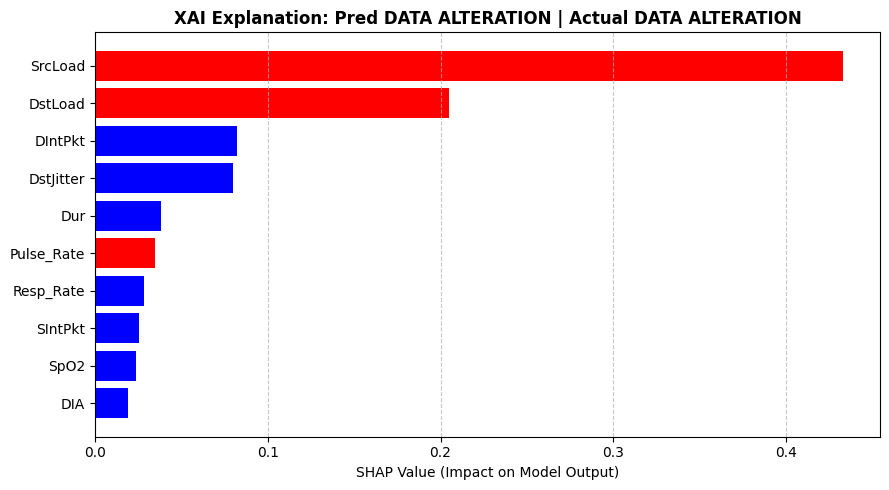

In [ ]:
plt.figure(figsize=(9, 5))

colors = ['red' if abs(v) > 1.0 else 'blue' for v in vals[::-1]]
plt.barh(names[::-1], scores[::-1], color=colors)
plt.title(f"XAI Explanation: Pred {enc.classes_[predicted_label].upper()} | Actual {enc.classes_[true_label].upper()}", fontweight='bold')
plt.xlabel("SHAP Value (Impact on Model Output)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()